In [2]:

import tensorflow as tf
import numpy as np
import random
import os

In [3]:
# Set a fixed seed value for reproducibility
SEED = 1
random.seed(SEED)            # Python random module
np.random.seed(SEED)         # NumPy
tf.random.set_seed(SEED)     # TensorFlow


In [4]:
# Enforce deterministic behavior for GPU operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Ensure deterministic execution
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Deterministic cuDNN algorithms


In [5]:
# Control GPU memory allocation (prevents TensorFlow from using all GPU memory)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  # Enable memory growth

# Restrict parallelism (ensures consistent execution order)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

In [6]:
# import os
import scipy.io #to load matlab files 
# import numpy as np
from sklearn.model_selection import train_test_split #for data splitting #, KFold
from sklearn.metrics import confusion_matrix
# import tensorflow as tf
from tensorflow.keras import layers, models #build and train CNN model
import matplotlib.pyplot as plt #for plotting confusion matrices and accuracy metrics
import seaborn as sns 
# import pandas as pd

from scipy import signal #for computing spectograms
from skimage.transform import resize #for resizing data
from sklearn.model_selection import StratifiedKFold

In [7]:
"""
# -----------------------------------------------------------------------------
# Read CWRU Bearing Data (Load - 2HP)
# -----------------------------------------------------------------------------
"""
def ImportData():
  folder_path = 'CWRU_BearingData_Load_2HP' 
  # X99_normal = scipy.io.loadmat('content/drive/MyDrive/BearingData_CaseWestern/99.mat')['X099_DE_time'] 
  file_path1 = os.path.join(folder_path, '99.mat')
  X99_normal = scipy.io.loadmat(file_path1)['X099_DE_time'] #vibration data extracted from X099_DE_time key (drive-end accelerometer data)

    
  # X111_InnerRace_007 = scipy.io.loadmat('/content/drive/MyDrive/BearingData_CaseWestern/111.mat')['X111_DE_time']
  file_path2 = os.path.join(folder_path, '111.mat')
  X111_InnerRace_007  = scipy.io.loadmat(file_path2)['X111_DE_time']

  # X124_Ball_007 = scipy.io.loadmat('/content/drive/MyDrive/BearingData_CaseWestern/124.mat')['X124_DE_time']
  file_path3 = os.path.join(folder_path, '124.mat')
  X124_Ball_007 = scipy.io.loadmat(file_path3)['X124_DE_time']

  # X137_Outer_007 = scipy.io.loadmat('/content/drive/MyDrive/BearingData_CaseWestern/137.mat')['X137_DE_time']
  file_path4 = os.path.join(folder_path, '137.mat')
  X137_Outer_007 = scipy.io.loadmat(file_path4)['X137_DE_time']
    
  # X176_InnerRace_014 = scipy.io.loadmat('/content/drive/MyDrive/BearingData_CaseWestern/176.mat')['X176_DE_time']
  file_path5 = os.path.join(folder_path, '176.mat')
  X176_InnerRace_014 = scipy.io.loadmat(file_path5)['X176_DE_time']

  # X191_Ball_014 = scipy.io.loadmat('/content/drive/MyDrive/BearingData_CaseWestern/191.mat')['X191_DE_time']
  file_path6 = os.path.join(folder_path, '191.mat')
  X191_Ball_014 = scipy.io.loadmat(file_path6)['X191_DE_time']
    
  # X203_Outer_014 = scipy.io.loadmat('/content/drive/MyDrive/BearingData_CaseWestern/203.mat')['X203_DE_time']
  file_path7 = os.path.join(folder_path, '203.mat')
  X203_Outer_014  = scipy.io.loadmat(file_path7)['X203_DE_time']

  #  X215_InnerRace_021 = scipy.io.loadmat('/content/drive/MyDrive/BearingData_CaseWestern/215.mat')['X215_DE_time']
  file_path8 = os.path.join(folder_path, '215.mat')
  X215_InnerRace_021  = scipy.io.loadmat(file_path8)['X215_DE_time']
    
  # X228_Ball_021 = scipy.io.loadmat('/content/drive/MyDrive/BearingData_CaseWestern/228.mat')['X228_DE_time']
  file_path9 = os.path.join(folder_path, '228.mat')
  X228_Ball_021  = scipy.io.loadmat(file_path9)['X228_DE_time']

  # X240_Outer_021 = scipy.io.loadmat('/content/drive/MyDrive/BearingData_CaseWestern/240.mat')['X240_DE_time']
  file_path10 = os.path.join(folder_path, '240.mat')
  X240_Outer_021  = scipy.io.loadmat(file_path10)['X240_DE_time'] 
  
    
  return [X99_normal,X111_InnerRace_007,X124_Ball_007,X137_Outer_007,X176_InnerRace_014,X191_Ball_014,X203_Outer_014,X215_InnerRace_021,X228_Ball_021,X240_Outer_021]

In [58]:
# -----------------------------------------------------------------------------
# Data Processing and Feature Extraction
# -----------------------------------------------------------------------------
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
# Segments the time-series data into smaller blocks for processing
# data: 1D numpy array of vibration data
# interval_length: step size (in samples) between the start of consecutive blocks
# samples_per_block: number of samples in each block (fixed at 1600 in the code)
# ignore_points: number of points to skip at start and end of data (default is 0)
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    # Adjust data length to ignore the first and last 'ignore_points'
    adjusted_length = len(Data) - 2 * ignore_points
    # Adjust the number of blocks
    No_of_blocks = (round(adjusted_length / interval_length) - round(samples_per_block / interval_length) - 1)
    print(f"\nNo of blocks {No_of_blocks}:")
    SplitData = np.zeros([No_of_blocks, samples_per_block])  # SplitData matrix where each row is a block of samples_per_block samples
    
    for i in range(No_of_blocks):
        # Skip the first 'ignore_points' and start sampling from that position
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx:(start_idx + samples_per_block)].T  # .T transpose ensures correct orientation
    
    return SplitData  # 2D array of shape (No_of_blocks, samples_per_block)

def DataPreparation(Data, interval_length, samples_per_block):
    # Initialize lists to store split and sampled data
    train_data_list = []
    train_y_list = []
    train_y1_list = []
    test_data_list = []
    test_y_list = []
    test_y1_list = []

    # Split each dataset into 80% train and 20% test
    for count, dataset in enumerate(Data):
        # Ensure dataset is 1D
        dataset = np.array(dataset).flatten()
        
        # Split into 80% train and 20% test
        train_data, test_data = train_test_split(
            dataset, train_size=0.8, test_size=0.2, random_state=42, shuffle=True
        )
        
        # Sample non-overlapping blocks for train data
        train_split_data = Sampling(train_data, interval_length, samples_per_block)
        print(f"\nIteration {count} - Train:")
        print(f"train_split_data shape: {train_split_data.shape}")
        print(f"Sample train_split_data values (first 5 elements of first block): {train_split_data[0][:5] if train_split_data.size > 0 else 'Empty'}")
        
        # Create one-hot encoded labels (y) for train
        train_y = np.zeros([len(train_split_data), 10])  # Shape (No_of_blocks, 10)
        train_y[:, count] = 1
        print(f"train_y shape: {train_y.shape}")
        print(f"Sample train_y values (first 5 blocks): {train_y[:5]}")
        
        # Create integer labels (y1) for train
        train_y1 = np.zeros([len(train_split_data), 1])  # Shape (No_of_blocks, 1)
        train_y1[:, 0] = count
        print(f"train_y1 shape: {train_y1.shape}")
        print(f"Sample train_y1 values (first 5 blocks): {train_y1[:5]}")
        
        # Sample non-overlapping blocks for test data
        test_split_data = Sampling(test_data, interval_length, samples_per_block)
        print(f"\nIteration {count} - Test:")
        print(f"test_split_data shape: {test_split_data.shape}")
        print(f"Sample test_split_data values (first 5 elements of first block): {test_split_data[0][:5] if test_split_data.size > 0 else 'Empty'}")
        
        # Create one-hot encoded labels (y) for test
        test_y = np.zeros([len(test_split_data), 10])  # Shape (No_of_blocks, 10)
        test_y[:, count] = 1
        print(f"test_y shape: {test_y.shape}")
        print(f"Sample test_y values (first 5 blocks): {test_y[:5]}")
        
        # Create integer labels (y1) for test
        test_y1 = np.zeros([len(test_split_data), 1])  # Shape (No_of_blocks, 1)
        test_y1[:, 0] = count
        print(f"test_y1 shape: {test_y1.shape}")
        print(f"Sample test_y1 values (first 5 blocks): {test_y1[:5]}")
        
        # Append to lists
        train_data_list.append(train_split_data)
        train_y_list.append(train_y)
        train_y1_list.append(train_y1)
        test_data_list.append(test_split_data)
        test_y_list.append(test_y)
        test_y1_list.append(test_y1)

    # Merge all train and test data
    X_train = np.concatenate(train_data_list, axis=0)
    X_test = np.concatenate(test_data_list, axis=0)
    Y_train = np.concatenate(train_y_list, axis=0)
    Y_test = np.concatenate(test_y_list, axis=0)
    y_train = np.concatenate(train_y1_list, axis=0)
    y_test = np.concatenate(test_y1_list, axis=0)

    # Reshape to (n_samples, 40, 40, 1) for CNN
    X_2D_train = X_train.reshape(-1, 40, 40, 1)
    X_2D_test = X_test.reshape(-1, 40, 40, 1)

    # One-hot encode labels
    y_2D_train = to_categorical(y_train.flatten(), num_classes=10)
    y_2D_test = to_categorical(y_test.flatten(), num_classes=10)
    y_label_train = y_train  # Integer labels
    y_label_test = y_test    # Integer labels

    print(f"\nFinal X_train shape: {X_train.shape}")
    print(f"Sample X_train values (first 5 elements of first block): {X_train[0][:5] if X_train.size > 0 else 'Empty'}")
    print(f"X_train: {X_train}")
    print(f"Final Y_train shape: {Y_train.shape}")
    print(f"Sample Y_train values (first 5 blocks): {Y_train[:5]}")
    print(f"Y_train: {Y_train}")
    print(f"Final y_train shape: {y_label_train.shape}")
    print(f"Sample y_train values (first 5 blocks): {y_label_train[:5]}")
    print(f"y_train: {y_label_train}")

    print(f"\nFinal X_test shape: {X_test.shape}")
    print(f"Sample X_test values (first 5 elements of first block): {X_test[0][:5] if X_test.size > 0 else 'Empty'}")
    print(f"X_test: {X_test}")
    print(f"Final Y_test shape: {Y_test.shape}")
    print(f"Sample Y_test values (first 5 blocks): {Y_test[:5]}")
    print(f"Y_test: {Y_test}")
    print(f"Final y_test shape: {y_label_test.shape}")
    print(f"Sample y_test values (first 5 blocks): {y_label_test[:5]}")
    print(f"y_test: {y_label_test}")

    return X_2D_train, X_2D_test, Y_train, Y_test , y_label_train, y_label_test



In [24]:

# import numpy as np
# from sklearn.model_selection import train_test_split

# # Assuming Data is a list of 10 datasets (one per class)
# # Define class labels (0 to 9)
# Data = ImportData()
# class_labels = np.arange(10)

# # Initialize lists to store split data
# train_data_list = []
# train_labels_list = []
# test_data_list = []
# test_labels_list = []

# # Split each dataset
# for idx, dataset in enumerate(Data):
#     # Ensure dataset is 1D
#     dataset = np.array(dataset).flatten()
    
#     # Split into 80% train and 20% test, stratified by class (though single class per dataset)
#     train_data, test_data = train_test_split(
#         dataset, train_size=0.8, test_size=0.2, random_state=42, shuffle=True
#     )
    
#     # Generate labels for this class
#     train_labels = np.full(len(train_data), idx)  # All train samples get class idx
#     test_labels = np.full(len(test_data), idx)    # All test samples get class idx
    
#     # Append to lists
#     train_data_list.append(train_data)
#     train_labels_list.append(train_labels)
#     test_data_list.append(test_data)
#     test_labels_list.append(test_labels)

# # Convert lists to numpy arrays
# X_train_raw = np.concatenate(train_data_list, axis=0)
# X_test_raw = np.concatenate(test_data_list, axis=0)
# y_train_raw = np.concatenate(train_labels_list, axis=0)
# y_test_raw = np.concatenate(test_labels_list, axis=0)

# print(f"X_train_raw shape: {X_train_raw.shape}")
# print(f"X_test_raw shape: {X_test_raw.shape}")
# print(f"y_train_raw shape: {y_train_raw.shape}")
# print(f"y_test_raw shape: {y_test_raw.shape}")





X_train_raw shape: (3898605,)
X_test_raw shape: (974655,)
y_train_raw shape: (3898605,)
y_test_raw shape: (974655,)


In [59]:
interval_length = 1600 #320 #290 #200  
samples_per_block = 1600 #1600 #1650-25*2
X_2D_train, X_2D_test, y_2D_train, y_2D_test, y_label_train, y_label_test  = DataPreparation(Data, interval_length, samples_per_block)


No of blocks 241:

Iteration 0 - Train:
train_split_data shape: (241, 1600)
Sample train_split_data values (first 5 elements of first block): [ 0.01460308 -0.03629908  0.01209969 -0.04547815  0.01376862]
train_y shape: (241, 10)
Sample train_y values (first 5 blocks): [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
train_y1 shape: (241, 1)
Sample train_y1 values (first 5 blocks): [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]

No of blocks 59:

Iteration 0 - Test:
test_split_data shape: (59, 1600)
Sample test_split_data values (first 5 elements of first block): [-0.01126523  0.03233538 -0.03775938  0.00479815 -0.04005415]
test_y shape: (59, 10)
Sample test_y values (first 5 blocks): [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
test_y1 shape: (59, 1)
Sample test_y1 v

In [ ]:
def min_max_norm(ary):
    ary = (ary - ary.min()) / np.abs(ary.max() - ary.min())
    return ary

def generate_spectrogram_image(data_y_vector, image_shape):
    """
    Calculate the spectrogram of an array data_y_vector and resize it in 
    the image_shape resolution
    """
    fs = 48000
    # data_y_vector_len = np.shape(data_y_vector)[0]

    f, t, sxx = signal.spectrogram(
        data_y_vector,
        fs)

    sxx = min_max_norm(sxx)
    sxx = resize(sxx, image_shape, mode='constant', anti_aliasing=True)

    return sxx


In [46]:
# ##Visualising normal form dataset of first 1600 data points(1 block) as a 40x40 image

# import math 
# from scipy import signal
# # Load the data
# data = scipy.io.loadmat('CWRU_BearingData_Load_2HP/99.mat')
# signal_data = data['X099_DE_time'].flatten()

# plt.figure(figsize=(15, 4))
# plt.plot(signal_data)
# plt.title('Full 1D Time-Series Signal - Healthy')
# plt.xlabel('Sample Index')
# plt.ylabel('Amplitude')
# plt.show()

# # Calculate max square size
# length = len(signal_data)
# side = int(math.sqrt(length))
# trim_size = side * side

# signal_trimmed = signal_data[:trim_size]

# # Reshape
# image1 = signal_trimmed.reshape((side, side))

# # Plot image
# plt.figure(figsize=(6, 6))
# plt.imshow(image1, cmap='gray', aspect='auto')
# plt.title(f'{side}x{side} Full 1D Image Representation')
# plt.colorbar()
# plt.show()

# # Define segment size
# segment_size = 40 * 40  # = 1600

# # Extract the first segment
# segment = signal_data[:segment_size]

# # Reshape into a 40x40 image
# image = segment.reshape((40, 40))

# # Plot both time series and 40x40 image
# plt.figure(figsize=(10, 4))

# # Plot time-domain signal
# plt.subplot(1, 2, 1)
# plt.plot(segment)
# plt.title('Time-Domain Signal (First 1600 points)')
# plt.xlabel('Sample Index')
# plt.ylabel('Amplitude')

# # Plot image
# plt.subplot(1, 2, 2)
# plt.imshow(image, cmap='gray', aspect='auto')
# plt.title('40x40 Image Representation')
# plt.colorbar()



# # Compute spectrogram of the segment
# fs = 48000  # Sampling frequency

# f, t, Sxx = signal.spectrogram(segment, fs=fs, nperseg=256, noverlap=128)

# # Convert power spectrogram to dB scale and normalize
# Sxx_db = 10 * np.log10(Sxx + 1e-10)
# Sxx_norm = min_max_norm(Sxx_db)

# # Resize spectrogram to 40x40 (optional, for CNN input consistency)
# Sxx_resized = resize(Sxx_norm, (40, 40), mode='constant', anti_aliasing=True)

# # Plot time series, image, and spectrogram side by side
# plt.figure(figsize=(15, 4))

# # Spectrogram plot
# plt.subplot(1, 3, 3)
# plt.imshow(Sxx_resized, cmap='jet', aspect='auto', origin='lower')
# plt.title('Spectrogram (Resized 40x40)')
# plt.xlabel('Time bins')
# plt.ylabel('Frequency bins')
# plt.colorbar(label='Normalized Power (dB)')

# plt.tight_layout()
# plt.show()


In [45]:
# 


In [44]:
# #Visualising the time-domain data along with overlapping segments 320 interval-len (first 6 batches)

# import scipy.io
# import numpy as np
# import matplotlib.pyplot as plt

# # Load the .mat file
# mat_data = scipy.io.loadmat('CWRU_BearingData_Load_2HP/99.mat')
# signal = mat_data['X099_DE_time'].flatten()

# # Parameters
# segment_size = 1600  # 40x40
# step_size = 320

# # Generate image segments and corresponding raw signals
# def create_images_and_signals(signal, segment_size=1600, step=320, image_shape=(40, 40)):
#     images = []
#     raw_segments = []
#     for i in range(0, len(signal) - segment_size + 1, step):
#         segment = signal[i:i + segment_size]
#         image = segment.reshape(image_shape)
#         images.append(image)
#         raw_segments.append(segment)
#     return np.array(images), np.array(raw_segments)

# # Create data
# images, segments = create_images_and_signals(signal, segment_size, step_size)

# # Plot the first 6 pairs (signal + image)
# fig, axes = plt.subplots(6, 2, figsize=(12, 18))

# for i in range(6):
#     # Time-domain plot
#     axes[i, 0].plot(segments[i])
#     axes[i, 0].set_title(f'Time-Domain Segment {i+1}')
#     axes[i, 0].set_xlabel('Sample Index')
#     axes[i, 0].set_ylabel('Amplitude')

#     # Image plot with axis and colorbar
#     img = axes[i, 1].imshow(images[i], cmap='gray', aspect='auto')
#     axes[i, 1].set_title(f'Image Representation {i+1}')
#     axes[i, 1].set_xlabel('X-axis (40 samples)')
#     axes[i, 1].set_ylabel('Y-axis (40 samples)')
    
#     # Add colorbar
#     cbar = plt.colorbar(img, ax=axes[i, 1])
#     cbar.set_label('Amplitude')

# plt.tight_layout()
# plt.show()


In [43]:
# ## 2-Dimensional Convolutional Neural Network Classification

# # Reshape the data - 2 dimensional feed 
# Input_2D = X.reshape([-1,40,40,1])

# # Input_2D = X_image.reshape([-1,40,40,1])
# print(Input_2D.shape)


# # Cell for Visualizing Individual 2D Images

# ## Visualize Sample 40x40 Images
# import matplotlib.pyplot as plt
# import numpy as np

# # Assuming Input_2D is defined as X.reshape([-1, 40, 40, 1])
# print(f"Input_2D shape: {Input_2D.shape}")

# # Select a few samples to visualize (e.g., indices 0, 1, 2)
# n_samples = 3
# fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 5, 5))

# for i in range(n_samples):
#     axes[i].imshow(Input_2D[i, :, :, 0], cmap='gray')  # Use the first channel (0)
#     axes[i].set_title(f'Sample {i}')
#     axes[i].axis('off')  # Hide axes

# plt.suptitle('Sample 40x40 Images from Input_2D')
# plt.tight_layout()
# plt.show()
# # Cell for t-SNE Visualization of 40x40x1 Data

# ## t-SNE Projection of Input_2D
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
# from tensorflow.keras import models, layers

# # Assuming Input_2D and y_2D_test (or similar labels) are defined
# print(f"Input_2D shape: {Input_2D.shape}")

# # Flatten each 40x40x1 image into a 1D vector for t-SNE
# X_flat = Input_2D.reshape(Input_2D.shape[0], -1)  # Shape: (3036, 1600)

# # Apply t-SNE
# tsne = TSNE(n_components=2, random_state=1, perplexity=min(30, len(X_flat)-1))
# tsne_coords = tsne.fit_transform(X_flat)

# # Assuming y_2D_test contains true labels (e.g., one-hot encoded)
# y_true = np.argmax(Y_CNN, axis=1) if len(Y_CNN.shape) > 1 else Y_CNN

# # Plot
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=y_true, cmap='tab20', alpha=0.6)
# plt.title('t-SNE Projection of 40x40x1 Images')
# plt.xlabel('t-SNE Component 1')
# plt.ylabel('t-SNE Component 2')
# plt.legend(*scatter.legend_elements(), title="True Class Index", loc="upper right")
# plt.tight_layout()
# plt.show()

In [42]:
# # Cell where Input_2D is defined

# # Assuming X is defined from DataPreparation and Y or y_label contains the integer labels
# Input_2D = X.reshape([-1, 40, 40, 1])
# print(f"Input_2D shape: {Input_2D.shape}")  # Should be (3026, 40, 40, 1)

# # Verify class assignments for specific index ranges
# index_ranges = [
#     (0, 303, "Class 0"),      # Samples 0 to 302 or 303
#     (303, 606, "Class 1"),    # Samples 303 to 605 or 606
#     (606, 909, "Class 2"),    # Samples 606 to 908 or 909
#     (909, 1212, "Class 3"),   # Samples 909 to 1211 or 1212
#     (1212, 1515, "Class 4"),  # Samples 1212 to 1514 or 1515
#     (1515, 1818, "Class 5"),  # Samples 1515 to 1817 or 1818
#     (1818, 2121, "Class 6"),  # Samples 1818 to 2120 or 2121
#     (2121, 2424, "Class 7"),  # Samples 2121 to 2423 or 2424
#     (2424, 2727, "Class 8"),  # Samples 2424 to 2726 or 2727
#     (2727, 3030, "Class 9")   # Samples 2727 to 3029 or 3030
# ]

# for start, end, class_name in index_ranges:
#     if end > Input_2D.shape[0]:  # Adjust end if total samples are 3026
#         end = Input_2D.shape[0]
#     labels_in_range = Y[start:end] if start < Input_2D.shape[0] else []
#     if labels_in_range.size > 0:
#         unique_labels = np.unique(labels_in_range)
#         print(f"\n{class_name} (indices {start} to {end-1}):")
#         print(f"Labels found: {unique_labels}")
#         print(f"Sample count: {len(labels_in_range)}")
#         print(f"First few labels: {labels_in_range[:5]}")
#     else:
#         print(f"\n{class_name} (indices {start} to {end-1}): No samples in range")

# # Optional: Check a sample image and its label
# sample_idx = 0
# print(f"\nSample {sample_idx} image shape: {Input_2D[sample_idx].shape}")
# print(f"Corresponding label: {Y[sample_idx]}")

In [41]:
# # Cell after train_test_split

# # Perform the split
# X_2D_train, X_2D_test, y_2D_train, y_2D_test, y_label_train, y_label_test = train_test_split(
#     Input_2D, Y_CNN, Y, train_size=0.8, test_size=0.2, random_state=42, stratify=Y
# )

# # Total samples
# total_samples = Input_2D.shape[0]
# print(f"Total samples: {total_samples}")

# # Original class distribution
# unique_classes, class_counts = np.unique(Y, return_counts=True)
# print("\nOriginal class distribution:")
# for cls, count in zip(unique_classes, class_counts):
#     print(f"Class {int(cls)}: {count} samples ({count/total_samples*100:.1f}%)")

# # Training set class distribution
# unique_train, train_counts = np.unique(y_label_train, return_counts=True)
# print("\nTraining set class distribution (80%):")
# for cls, count in zip(unique_train, train_counts):
#     print(f"Class {int(cls)}: {count} samples ({count/len(y_label_train)*100:.1f}%)")

# # Testing set class distribution (20%)
# unique_test, test_counts = np.unique(y_label_test, return_counts=True)
# print("\nTesting set class distribution (20%):")
# for cls, count in zip(unique_test, test_counts):
#     print(f"Class {int(cls)}: {count} samples ({count/len(y_label_test)*100:.1f}%)")

# # Check a few random sample indices in training and testing sets
# np.random.seed(42)  # For reproducibility of random checks
# random_train_indices = np.random.choice(len(X_2D_train), 5, replace=False)
# random_test_indices = np.random.choice(len(X_2D_test), 5, replace=False)
# print("\nRandom training set indices and their original positions:")
# for idx in random_train_indices:
#     original_idx = np.where((Y == y_label_train[idx]))[0][0]  # Approximate original index
#     print(f"Train index {idx}, Original index: {original_idx}, Label: {y_label_train[idx][0]}")
# print("\nRandom testing set indices and their original positions:")
# for idx in random_test_indices:
#     original_idx = np.where((Y == y_label_test[idx]))[0][0]  # Approximate original index
#     print(f"Test index {idx}, Original index: {original_idx}, Label: {y_label_test[idx][0]}")

# # Optional: Check if sequential order is broken
# first_10_train_labels = y_label_train[:10].flatten()
# first_10_test_labels = y_label_test[:10].flatten()
# print("\nFirst 10 labels in training set:", first_10_train_labels)
# print("First 10 labels in testing set:", first_10_test_labels)

In [60]:
# X_2D_train, X_2D_test, y_2D_train, y_2D_test = train_test_split(Input_2D, Y_CNN, train_size=0.8, test_size=0.2, random_state=42, shuffle=True)
print(f"X_2D_train shape: {X_2D_train.shape}")  # Should be (~2429, 40, 40, 1)
print(f"X_2D_test shape: {X_2D_test.shape}")    # Should be (~607, 40, 40, 1)
print(f"y_2D_train shape: {y_2D_train.shape}")  # Should be (~2429, 10)
print(f"y_2D_test shape: {y_2D_test.shape}")    # Should be (~607, 10)
print(f"y_label_train shape: {y_label_train.shape}")  # Should be (~2429, 1) or (~2429,)
print(f"y_label_test shape: {y_label_test.shape}")

# Define the CNN Classification model
class CNN_2D():
  def __init__(self):
    self.model = self.CreateModel()

  def CreateModel(self):
    model = models.Sequential([
        # layers.Conv2D(filters=16, kernel_size=(3,3), strides=(2,2), padding ='same',activation='relu'),
        layers.Conv2D(filters=16, kernel_size=(3,3), padding='same',activation='relu', input_shape=(40,40,1)),
        layers.MaxPool2D(pool_size=(2,2), padding='same'),
        layers.Conv2D(filters=32, kernel_size=(3,3), padding ='same',activation='relu'),
        layers.MaxPool2D(pool_size=(2,2), padding='same'),
        layers.Conv2D(filters=64, kernel_size=(3,3),padding ='same', activation='relu'),
        layers.MaxPool2D(pool_size=(2,2), padding='same'),
        layers.Conv2D(filters=128, kernel_size=(3,3),padding ='same', activation='relu'),
        layers.MaxPool2D(pool_size=(2,2), padding='same'),
        layers.Flatten(),
        layers.Dense(100,activation='relu'),
        layers.Dense(50,activation='relu'),
        layers.Dense(10),
        layers.Softmax()
        ])
    model.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])
    return model

X_2D_train shape: (2417, 40, 40, 1)
X_2D_test shape: (590, 40, 40, 1)
y_2D_train shape: (2417, 10)
y_2D_test shape: (590, 10)
y_label_train shape: (2417, 1)
y_label_test shape: (590, 1)


In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score
# k-fold cross validation / 5 fold cross validation )
print(f"X_2D_train shape: {X_2D_train.shape}")
print(f"X_2D_test shape: {X_2D_test.shape}")
kSplits = 5
# kfold = KFold(n_splits=kSplits, random_state=42, shuffle=True)
kfold = StratifiedKFold(n_splits=kSplits, random_state=42, shuffle=True) # splits training data into 5 folds - class balance(stratify)

# File path name to save best models
foldername = "CNN2D_results/train-test/"

from tensorflow.keras.callbacks import ModelCheckpoint #Saves the model with the highest validation accuracy for each fold
from tensorflow.keras.callbacks import EarlyStopping 
from tensorflow.keras.models import load_model 

accuracy_train = []
accuracy_val = []
accuracy_test = []
precision_val = []
recall_val = []
f1_val = []
pred_all_val = np.zeros([len(X_2D_train),10])
y_2D_val = np.zeros([len(X_2D_train),10])
kfold_test_len = []

fl1 = 0
k = 1

early_stop = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True) #Stops training if validation accuracy doesn’t improve for 50 epochs, restoring the best weights.

# Train the model 
# for train, test in kfold.split(X_2D_train,y_2D_train):
for fold, (train, test) in enumerate(kfold.split(X_2D_train, y_label_train)):   

  # Define where to save the best model
  checkpoint_filepath = foldername + "best_model_" + str(k) + ".h5"
    
  # Create a ModelCheckpoint callback
  checkpoint = ModelCheckpoint(
      filepath=checkpoint_filepath,
      monitor='val_accuracy',  # Monitor validation accuracy
      save_best_only=True,  # Save only the best model
      mode='max',  # Maximize accuracy
      verbose=1
  )        

#For each fold, trains a new CNN model on the training subset (X_2D_train[train], y_2D_train[train]) for up to 200 epochs.
  Classification_2D = CNN_2D()
  # history = Classification_2D.model.fit(X_2D_train[train], y_2D_train[train], verbose=1, epochs=50) #epochs=12
  history = Classification_2D.model.fit(
        X_2D_train[train], y_2D_train[train],
        validation_data=(X_2D_train[test], y_2D_train[test]),  # Validation set for monitoring
        epochs=200,
        verbose=1,
        callbacks=[checkpoint, early_stop]  # Save the best model
  )
  
  print("Best model saved at:", checkpoint_filepath)
  CNN_2D_best_model = load_model(checkpoint_filepath)
  print("Best model loaded successfully!")
  
  fl2 = fl1 + len(test)
  pred_all_val[fl1:fl2,:] = CNN_2D_best_model.predict(X_2D_train[test])
  y_2D_val[fl1:fl2,:] = y_2D_train[test]
  kfold_test_len.append(fl2-fl1)
  fl1 = fl2  

  # Evaluate the accuracy of the model on the training set 
  train_loss, train_accuracy = CNN_2D_best_model.evaluate(X_2D_train[train], y_2D_train[train]) 
  accuracy_train.append(train_accuracy)
  
  # Evaluate the accuracy of the model on the validation set 
  val_loss, val_accuracy = CNN_2D_best_model.evaluate(X_2D_train[test], y_2D_train[test]) 
  accuracy_val.append(val_accuracy)
  
  # Evaluate the accuracy of the model on the validation set 
  test_loss, test_accuracy = CNN_2D_best_model.evaluate(X_2D_test, y_2D_test) 
  accuracy_test.append(test_accuracy) 

  # Calculate precision, recall, and F1 score for validation set
  y_pred_val = np.argmax(CNN_2D_best_model.predict(X_2D_train[test]), axis=1)
  y_true_val = np.argmax(y_2D_train[test], axis=1)
  precision_val.append(precision_score(y_true_val, y_pred_val, average='weighted'))
  recall_val.append(recall_score(y_true_val, y_pred_val, average='weighted'))
  f1_val.append(f1_score(y_true_val, y_pred_val, average='weighted'))
  
  # Evaluate the accuracy of the model on the training set 
  # kf_loss, kf_accuracy = Classification_2D.model.evaluate(X_2D_train[test], y_2D_train[test]) 
  # accuracy_2D.append(kf_accuracy)
  
  k = k + 1

X_2D_train shape: (2417, 40, 40, 1)
X_2D_test shape: (590, 40, 40, 1)
Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-19 12:17:42.926913: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown a

59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1430 - loss: 2.1434
Epoch 1: val_accuracy improved from -inf to 0.35331, saving model to CNN2D_results/train-test/best_model_1.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.1458 - loss: 2.1363 - val_accuracy: 0.3533 - val_loss: 1.5437
Epoch 2/200
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5993 - loss: 0.9985
Epoch 2: val_accuracy improved from 0.35331 to 0.79752, saving model to CNN2D_results/train-test/best_model_1.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6018 - loss: 0.9908 - val_accuracy: 0.7975 - val_loss: 0.4634
Epoch 3/200
59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7737 - loss: 0.4733
Epoch 3: val_accuracy did not improve from 0.79752
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7731 - loss: 0.4744 - val_accuracy: 0.7872 - val_loss: 0.4942
Epoch 4/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8197 - loss: 0.3982
Epoch 4: val_accuracy improved from 0.79752 to 0.91736, saving model to CNN2D_results/train-test/best_model_1.h5


...

61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9608 - loss: 0.0965 - val_accuracy: 0.9524 - val_loss: 0.1237
Epoch 30/200
59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9587 - loss: 0.0973
Epoch 30: val_accuracy did not improve from 0.95238
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9587 - loss: 0.0972 - val_accuracy: 0.9524 - val_loss: 0.1163
Epoch 31/200
59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9584 - loss: 0.0928
Epoch 31: val_accuracy improved from 0.95238 to 0.95445, saving model to CNN2D_results/train-test/best_model_5.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9585 - loss: 0.0924 - val_accuracy: 0.9545 - val_loss: 0.1157
Epoch 32/200
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9530 - loss: 0.1150
Epoch 32: val_accuracy did not improve from 0.95445
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9527 - loss: 0.1158 - val_accuracy: 0.9193 - val_loss: 0.1685
Epoch 33/200
59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9618 - loss: 0.1013
Epoch 33: val_accuracy did not improve from 0.95445
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9616 - loss: 0.1013 - val_accuracy: 0.9482 - val_loss: 0.1066
Epoch 34/200
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9496 - loss: 0.1388
Epoch 34: val_accuracy did not improve from 0.95445
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9496 - loss: 0.1388 - val_accuracy: 0.9420 - val_loss: 0.1533
Epoch 35/200
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9412 - loss: 0.1257
Epoch 35: val_accuracy did not i

Best model saved at: CNN2D_results/train-test/best_model_5.h5
Best model loaded successfully!
 6/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

2025-06-19 12:34:39.328090: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-19 12:34:39.328898: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9852 - loss: 0.0476
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9697 - loss: 0.0947
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9772 - loss: 0.0693
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


CNN 2D train accuracy = 98.26233148574829
CNN 2D validation accuracy = 95.86237788200378
CNN 2D test accuracy = 96.5762722492218
11/76 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

2025-06-19 13:18:30.136464: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-19 13:18:30.137766: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


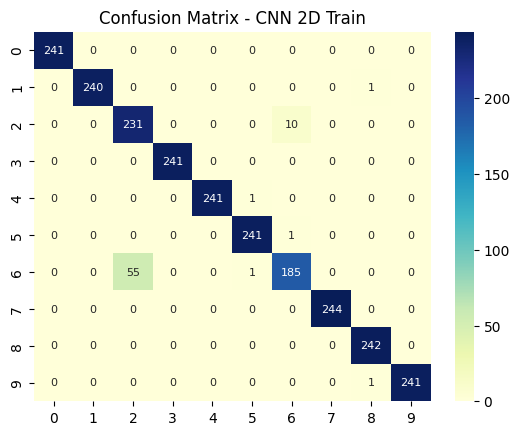

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


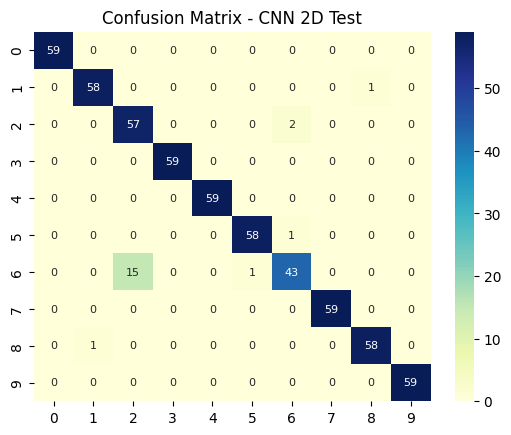

In [69]:
"""
# -----------------------------------------------------------------------------
# Multiclass Classification CNN Model Evaluation
# -----------------------------------------------------------------------------
"""

# Classification_2D.model.summary()

CNN_2D_train_accuracy = np.average(accuracy_train)*100
print('CNN 2D train accuracy =', CNN_2D_train_accuracy)
# print(accuracy_train)

CNN_2D_val_accuracy = np.average(accuracy_val)*100
print('CNN 2D validation accuracy =', CNN_2D_val_accuracy)
# print(accuracy_val)

CNN_2D_test_accuracy = np.average(accuracy_test)*100
print('CNN 2D test accuracy =', CNN_2D_test_accuracy)
# print(accuracy_test)

# Evaluate the accuracy of the model on the test set
# CNN_2D_test_loss, CNN_2D_test_accuracy = Classification_2D.model.evaluate(X_2D_test, y_2D_test)
# CNN_2D_test_accuracy*=100
# print('CNN 2D test accuracy =', CNN_2D_test_accuracy)


def ConfusionMatrix(Model, X, y):
  y_pred = np.argmax(Model.predict(X), axis=1)
  ConfusionMat = confusion_matrix(np.argmax(y, axis=1), y_pred)
  return ConfusionMat

# Plot results - CNN 2D
plt.figure(5)
plt.title('Confusion Matrix - CNN 2D Train') 
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_train, y_2D_train) , annot=True, fmt='d',annot_kws={"fontsize":8},cmap="YlGnBu")
plt.show()

plt.figure(6)
plt.title('Confusion Matrix - CNN 2D Test') 
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_test, y_2D_test) , annot=True, fmt='d',annot_kws={"fontsize":8},cmap="YlGnBu")
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


2025-06-19 13:18:41.002591: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-19 13:18:41.002877: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN 2D Validation Precision = 96.19%
CNN 2D Validation Recall = 95.86%
CNN 2D Validation F1 Score = 95.79%
CNN 2D Test Precision = 96.76%
CNN 2D Test Recall = 96.44%
CNN 2D Test F1 Score = 96.38%


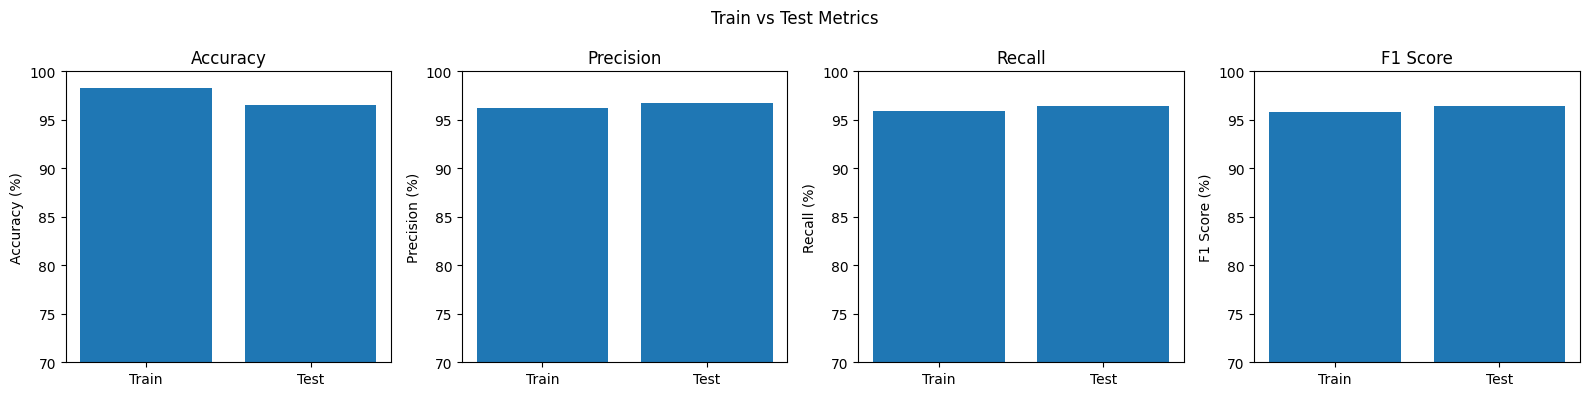

In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

CNN_2D_val_precision = np.average(precision_val) * 100
CNN_2D_val_recall = np.average(recall_val) * 100
CNN_2D_val_f1 = np.average(f1_val) * 100

# Calculate metrics for test set
y_pred_test = np.argmax(CNN_2D_best_model.predict(X_2D_test), axis=1)
y_true_test = np.argmax(y_2D_test, axis=1)
CNN_2D_test_precision = precision_score(y_true_test, y_pred_test, average='weighted') * 100
CNN_2D_test_recall = recall_score(y_true_test, y_pred_test, average='weighted') * 100
CNN_2D_test_f1 = f1_score(y_true_test, y_pred_test, average='weighted') * 100

print('CNN 2D Validation Precision = {:.2f}%'.format(CNN_2D_val_precision))
print('CNN 2D Validation Recall = {:.2f}%'.format(CNN_2D_val_recall))
print('CNN 2D Validation F1 Score = {:.2f}%'.format(CNN_2D_val_f1))
print('CNN 2D Test Precision = {:.2f}%'.format(CNN_2D_test_precision))
print('CNN 2D Test Recall = {:.2f}%'.format(CNN_2D_test_recall))
print('CNN 2D Test F1 Score = {:.2f}%'.format(CNN_2D_test_f1))

# Plot train vs test metrics
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Train vs Test Metrics')

ax1.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
ax1.set_title('Accuracy')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Train', 'Test'])
ax1.set_ylim([70, 100])

ax2.bar([1, 2], [CNN_2D_val_precision, CNN_2D_test_precision])
ax2.set_title('Precision')
ax2.set_ylabel('Precision (%)')
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Train', 'Test'])
ax2.set_ylim([70, 100])

ax3.bar([1, 2], [CNN_2D_val_recall, CNN_2D_test_recall])
ax3.set_title('Recall')
ax3.set_ylabel('Recall (%)')
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Train', 'Test'])
ax3.set_ylim([70, 100])

ax4.bar([1, 2], [CNN_2D_val_f1, CNN_2D_test_f1])
ax4.set_title('F1 Score')
ax4.set_ylabel('F1 Score (%)')
ax4.set_xticks([1, 2])
ax4.set_xticklabels(['Train', 'Test'])
ax4.set_ylim([70, 100])

plt.tight_layout()
plt.show()